# Spiral classification: Forward AJ, Inverse AJ, and ReLU MLP

This notebook trains three classifiers on a **2D spiral dataset** (similar to the [TensorFlow Playground](https://playground.tensorflow.org/#activation=relu&batchSize=10&dataset=spiral&problem=classification)):

1. **Forward AJ** — Map (x,y) into Jacobian space via the classical Abel–Jacobi forward map (genus = WIDTH/2), then a linear head. Poles/cuts are sampled randomly as in `higher_genus_lookup_tables.ipynb`.
2. **Inverse AJ** — Map (x,y) through a small MLP to Jacobian **u**, then through `InverseAbelJacobiNetwork` (same genus), then a linear head. Uses the same random cuts.
3. **ReLU MLP** — Single hidden layer: 2 → WIDTH → 2 (middle dimension = WIDTH).

A single **even** `WIDTH` controls everything: genus = WIDTH/2 for both AJ maps; the 1-layer MLP has hidden size WIDTH. All use cross-entropy loss; decision boundaries and accuracy are compared.

## Setup and paths

In [1]:
# Even width: genus = WIDTH//2 for both AJ maps; 1-layer MLP hidden size = WIDTH
WIDTH = 60
assert WIDTH >= 2 and WIDTH % 2 == 0, "WIDTH must be even and >= 2"
GENUS_SPIRAL = WIDTH // 2

# Random poles/cuts (same construction as higher_genus_lookup_tables.ipynb)
CUTS_SEED = 123
CUTS_RADIUS = 4.0
CUTS_JITTER = 0.25
GRID_BOUND = 4.0  # r_min, r_max, i_min, i_max for forward tables

print(f"WIDTH={WIDTH} → genus={GENUS_SPIRAL}, MLP hidden={WIDTH}")

WIDTH=60 → genus=30, MLP hidden=60


In [2]:
import sys
from pathlib import Path

for p in [Path.cwd(), Path.cwd().parent]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from src import util as aj_util

REPO_ROOT = aj_util.get_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Spiral dataset

Two interleaved spirals (class 0 and 1), with optional noise. Train/test split ~50% like the Playground.

Train: (200, 2) Test: (200, 2)


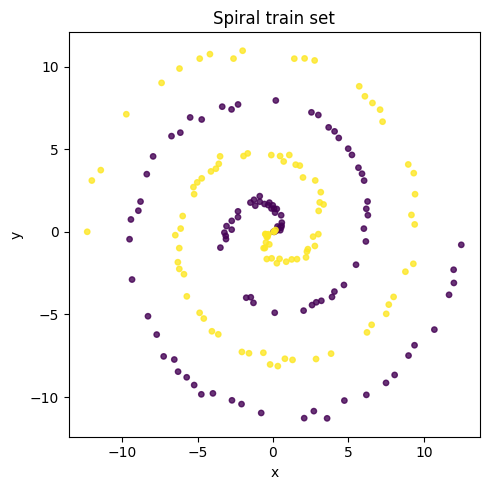

In [3]:
def make_spiral(n_per_class: int, n_classes: int = 2, noise: float = 0.2, seed: int = 42):
    """
    Generate 2D spiral data: n_per_class points per class on interleaved spirals.
    Returns X (n, 2), y (n,) in [0, n_classes).
    """
    rng = np.random.RandomState(seed)
    X_list, y_list = [], []
    for c in range(n_classes):
        t = 4*np.pi*(-1)**c * np.linspace(0, 1, n_per_class)
        r = t + noise * rng.randn(n_per_class)
        x = r * np.cos(t)
        y = (-1)**c * r * np.sin(t)
        X_list.append(np.stack([x, y], axis=1))
        y_list.append(np.full(n_per_class, c, dtype=np.int64))
    X = np.vstack(X_list)
    y = np.concatenate(y_list)
    perm = rng.permutation(len(y))
    return X[perm].astype(np.float32), y[perm]


N_PER_CLASS = 200
NOISE = 0.2
SEED = 42
X_all, y_all = make_spiral(N_PER_CLASS, n_classes=2, noise=NOISE, seed=SEED)

n = len(y_all)
rng = np.random.RandomState(SEED + 1)
idx = rng.permutation(n)
split = n // 2
train_idx, test_idx = idx[:split], idx[split:]

X_train, y_train = X_all[train_idx], y_all[train_idx]
X_test, y_test = X_all[test_idx], y_all[test_idx]

train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
test_ds = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))
train_loader = DataLoader(train_ds, batch_size=20, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=100)

print("Train:", X_train.shape, "Test:", X_test.shape)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="viridis", s=15, alpha=0.8)
ax.set_title("Spiral train set")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()

## ReLU MLP (baseline)

Single hidden layer: 2 → WIDTH → 2 (middle dimension = WIDTH).

In [4]:
class ReLUMLP(nn.Module):
    def __init__(self, in_dim=2, hidden=(8,), num_classes=2):
        super().__init__()
        layers = []
        d = in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU(inplace=True)]
            d = h
        self.backbone = nn.Sequential(*layers)
        self.classifier = nn.Linear(d, num_classes)

    def forward(self, x):
        return self.classifier(self.backbone(x))


mlp = ReLUMLP(in_dim=2, hidden=(WIDTH,), num_classes=2).to(device)
opt_mlp = torch.optim.Adam(mlp.parameters(), lr=0.03)

## Forward AJ (genus = WIDTH/2)

Forward tables are **loaded automatically** via `aj_util.get_or_build_forward_tables`: if precomputed tables exist for this genus/seed/radius/jitter/bounds, they are loaded from disk; otherwise they are built (mpmath) and saved for next time. Same loader as MNIST/scripts. Then (x,y) → grid lookup → AJ coords (2g) → linear classifier. One point (x,y) plus a fixed second point → A(P) + A(P_0).

In [5]:
def _pack_complex_table(table_gHW):
    re = torch.from_numpy(table_gHW.real).float()
    im = torch.from_numpy(table_gHW.imag).float()
    return torch.cat([re, im], dim=0).unsqueeze(0).contiguous()


class ForwardAJ2D(nn.Module):
    """
    Map (x,y) in [-scale, scale]^2 to grid, then one point (x,y) + fixed second point
    through AJ bilinear lookup -> (2g,) -> classifier.
    """
    def __init__(self, tables, num_classes=2, scale=6.0):
        super().__init__()
        g = tables["genus"]
        I_plus = tables["I_plus"]
        Om_plus = tables["omega_plus"]
        grid_r = tables["grid_r"]
        grid_i = tables["grid_i"]
        branch_pts = tables["branch_pts"]
        mu = torch.from_numpy(tables["mu"]).float()
        sigma = torch.from_numpy(tables["sigma"]).float()
        self.g = g
        self.scale = scale
        self.register_buffer("I_plus", _pack_complex_table(I_plus))
        self.register_buffer("Om_plus", _pack_complex_table(Om_plus))
        self.register_buffer("mu", mu.view(1, 1, -1))
        self.register_buffer("sigma", sigma.view(1, 1, -1))
        self.register_buffer("r_min", torch.tensor(float(grid_r.min())))
        self.register_buffer("r_max", torch.tensor(float(grid_r.max())))
        self.register_buffer("i_min", torch.tensor(float(grid_i.min())))
        self.register_buffer("i_max", torch.tensor(float(grid_i.max())))
        self.register_buffer("bp_real", torch.from_numpy(branch_pts.real).float())
        self.register_buffer("bp_imag", torch.from_numpy(branch_pts.imag).float())
        # Fixed second point (anchor) in grid coords
        anchor = (grid_r.min() + grid_r.max()) / 2 + 1j * (grid_i.min() + grid_i.max()) / 2
        self.register_buffer("anchor_real", torch.tensor(float(anchor.real)))
        self.register_buffer("anchor_imag", torch.tensor(float(anchor.imag)))
        self.classifier = nn.Linear(2 * g, num_classes)

    def _xy_to_grid(self, x, y):
        # Map [−scale, scale] to [r_min, r_max] and [i_min, i_max]
        xr = self.r_min + (self.r_max - self.r_min) * (x / self.scale + 1.0) / 2.0
        yi = self.i_min + (self.i_max - self.i_min) * (y / self.scale + 1.0) / 2.0
        return xr, yi

    def _norm_to_grid_sample(self, xr, yi):
        gx = 2.0 * (xr - self.r_min) / (self.r_max - self.r_min) - 1.0
        gy = 2.0 * (yi - self.i_min) / (self.i_max - self.i_min) - 1.0
        return gx, gy

    def forward(self, xy):
        B = xy.size(0)
        x, y = xy[:, 0], xy[:, 1]
        xr, yi = self._xy_to_grid(x, y)
        gx1, gy1 = self._norm_to_grid_sample(xr, yi)
        grid1 = torch.stack([gx1, gy1], dim=-1).view(B, 1, 1, 2)
        xr2 = self.anchor_real.expand(B)
        yi2 = self.anchor_imag.expand(B)
        gx2, gy2 = self._norm_to_grid_sample(xr2, yi2)
        grid2 = torch.stack([gx2, gy2], dim=-1).view(B, 1, 1, 2)
        I1 = F.grid_sample(
            self.I_plus.expand(B, -1, -1, -1),
            grid1, mode="bilinear", align_corners=True,
        ).view(B, -1)
        I2 = F.grid_sample(
            self.I_plus.expand(B, -1, -1, -1),
            grid2, mode="bilinear", align_corners=True,
        ).view(B, -1)
        I_std1 = (I1 - self.mu.view(-1)) / self.sigma.view(-1)
        I_std2 = (I2 - self.mu.view(-1)) / self.sigma.view(-1)
        coords = I_std1 + I_std2
        return self.classifier(coords)


# Use the shared loader: loads from data folder (e.g. data/AJ_Tables_g{genus}) when present, else builds and saves there.
tables, tables_found = aj_util.get_or_build_forward_tables(
    device,
    data_root=REPO_ROOT / "data",
    genus=GENUS_SPIRAL,
    grid_size=32,
    r_min=-GRID_BOUND,
    r_max=GRID_BOUND,
    i_min=-GRID_BOUND,
    i_max=GRID_BOUND,
    base_point=complex(-5.0, -5.0),
    seed=CUTS_SEED,
    radius=CUTS_RADIUS,
    jitter=CUTS_JITTER,
    auto_build=True,
)
tables_2d = aj_util.tables_for_spiral_forward(tables)
print(f"Forward tables: {tables_found}")
# Spiral data lives roughly in [-4π, 4π] ≈ [-12.5, 12.5]; scale so it maps into grid
forward_aj_2d = ForwardAJ2D(tables_2d, num_classes=2, scale=14.0).to(device)
opt_forward = torch.optim.Adam(forward_aj_2d.parameters(), lr=0.03)

Forward tables: /home/users/hshunt/Abel-Jacobi-Networks/data/AJ_Tables_g30


## Inverse AJ (genus = WIDTH/2)

Map (x,y) → Linear(2, 2g) → **u** → `InverseAbelJacobiNetwork` → coefficients → linear classifier. Branch points from the **same random cuts** as forward. For **genus ≤ 4**, Ω and K are computed from the curve (mpmath); for **genus > 4** the period computation is skipped and toy Ω/K are used so the cell does not hang (computing Ω/K for large genus requires thousands of quadratures).

In [ ]:
from aj.classical import InverseAbelJacobiNetwork, make_hyperelliptic_cuts

# Same random cuts as forward AJ (higher_genus_lookup_tables style)
cuts_inv = make_hyperelliptic_cuts(
    GENUS_SPIRAL, radius=CUTS_RADIUS, jitter=CUTS_JITTER, seed=CUTS_SEED,
    r_max=GRID_BOUND, r_min=-GRID_BOUND, i_max=GRID_BOUND, i_min=-GRID_BOUND,
)
branch_pts_inv = np.array([z for a, b in cuts_inv for z in (a, b)], dtype=np.complex128)
branch_points_inv = torch.tensor(np.stack([branch_pts_inv.real, branch_pts_inv.imag], axis=1), dtype=torch.float32)

# Kleinian P path always needs log_sigma_fun (toy is fine for this demo).
def _toy_log_sigma(v):
    v = np.asarray(v, dtype=np.complex128).ravel()
    if v.size == 1:
        return -(v[0] ** 3) / 6.0
    return -(v[0] ** 3) / 6.0 - 0.5 * v[0] * (v[1] ** 2)

# Period matrix Ω and K: computing them from branch points uses thousands of mpmath
# quadratures and is only practical for small genus (e.g. ≤4). For larger genus, use
# toy Ω/K so this cell finishes in seconds instead of hanging. use_kleinian_p stays True.
INVERSE_MAX_GENUS_FOR_PERIOD_COMPUTE = 4
if GENUS_SPIRAL <= INVERSE_MAX_GENUS_FOR_PERIOD_COMPUTE:
    Omega_init = None
    K_init = None
else:
    g = GENUS_SPIRAL
    Omega_init = (1.0 + 2.0j) * np.eye(g, dtype=np.complex128) + 0.1 * (np.ones((g, g)) - np.eye(g))
    Omega_init = (Omega_init + Omega_init.T) / 2
    K_init = np.zeros(g, dtype=np.complex128)
    print(f"Inverse AJ: genus {GENUS_SPIRAL} > {INVERSE_MAX_GENUS_FOR_PERIOD_COMPUTE}; using toy Ω, K (skip period computation).")

inv_net = InverseAbelJacobiNetwork(
    genus=GENUS_SPIRAL,
    branch_points=branch_points_inv,
    base_point=(-GRID_BOUND - 1.0, -GRID_BOUND - 1.0),
    init_divisor_points=torch.zeros(GENUS_SPIRAL, 2, dtype=torch.float32),
    use_kleinian_p=True,
    log_sigma_fun=_toy_log_sigma,
    Omega_init=Omega_init,
    K_init=K_init,
).to(device)


class InverseAJ2D(nn.Module):
    """(x,y) -> Linear(2, 2g) -> u (B, g, 2) -> InverseAbelJacobiNetwork -> Linear(g, num_classes)."""

    def __init__(self, inv_net_module, num_classes=2):
        super().__init__()
        self.g = inv_net_module.genus
        self.to_u = nn.Linear(2, 2 * self.g)
        self.inv_net = inv_net_module
        self.classifier = nn.Linear(self.g, num_classes)

    def forward(self, xy):
        u = self.to_u(xy).view(-1, self.g, 2)
        coeffs = self.inv_net(u)
        return self.classifier(coeffs)


inverse_aj_2d = InverseAJ2D(inv_net, num_classes=2).to(device)
opt_inverse = torch.optim.Adam(inverse_aj_2d.parameters(), lr=0.01)

In [ ]:
def train_epoch(model, loader, opt, device):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for xy, y in loader:
        xy, y = xy.to(device), y.to(device)
        opt.zero_grad()
        logits = model(xy)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        opt.step()
        total_loss += loss.item() * xy.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        n += xy.size(0)
    return total_loss / n, correct / n


def eval_model(model, loader, device):
    model.eval()
    correct, n = 0, 0
    with torch.no_grad():
        for xy, y in loader:
            xy, y = xy.to(device), y.to(device)
            logits = model(xy)
            correct += (logits.argmax(1) == y).sum().item()
            n += xy.size(0)
    return correct / n


def run_training(name, model, opt, n_epochs=400):
    train_accs, test_accs = [], []
    for ep in range(1, n_epochs + 1):
        train_loss, train_acc = train_epoch(model, train_loader, opt, device)
        test_acc = eval_model(model, test_loader, device)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        if ep % 100 == 0 or ep == 1:
            print(f"[{name}] Epoch {ep:3d} | train loss {train_loss:.4f} acc {train_acc:.2%} | test acc {test_acc:.2%}")
    return train_accs, test_accs

## Train all three models

In [ ]:
N_EPOCHS = 400
print("Training ReLU MLP...")
run_training("ReLU MLP", mlp, opt_mlp, n_epochs=N_EPOCHS)
print("Training Forward AJ...")
run_training("Forward AJ", forward_aj_2d, opt_forward, n_epochs=N_EPOCHS)
print("Training Inverse AJ...")
run_training("Inverse AJ", inverse_aj_2d, opt_inverse, n_epochs=N_EPOCHS)

## Decision boundaries

Plot test set and model decision boundaries on a 2D grid.

In [ ]:
def plot_decision_boundary(model, X_test, y_test, title, device, resolution=200):
    model.eval()
    x_min, x_max = X_test[:, 0].min() - 0.5, X_test[:, 0].max() + 0.5
    y_min, y_max = X_test[:, 1].min() - 0.5, X_test[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, resolution), np.linspace(y_min, y_max, resolution))
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    with torch.no_grad():
        logits = model(torch.from_numpy(grid).to(device))
        pred = logits.argmax(1).cpu().numpy()
    pred = pred.reshape(xx.shape)
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.contourf(xx, yy, pred, alpha=0.3, levels=np.linspace(-0.5, 1.5, 3), cmap="tab10")
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="viridis", s=15, alpha=0.9, edgecolors="k", linewidths=0.3)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.tight_layout()
    plt.show()


plot_decision_boundary(mlp, X_test, y_test, "ReLU MLP", device)
plot_decision_boundary(forward_aj_2d, X_test, y_test, "Forward AJ", device)
plot_decision_boundary(inverse_aj_2d, X_test, y_test, "Inverse AJ", device)

In [ ]:
# Final test accuracy comparison
for name, model in [("ReLU MLP", mlp), ("Forward AJ", forward_aj_2d), ("Inverse AJ", inverse_aj_2d)]:
    acc = eval_model(model, test_loader, device)
    print(f"{name}: test accuracy {acc:.2%}")